# 03 — Model Comparison, Evaluation & Explainability

Malicious URL Detection — Final Year Project

This notebook trains all five required models (Logistic Regression, Decision
Tree, Random Forest, SVM, XGBoost) under identical conditions, tunes three of
them via `RandomizedSearchCV`, selects the best model by F1-score (then
ROC-AUC as tiebreaker), evaluates it rigorously on the held-out test set, and
generates SHAP explainability outputs.

> **Notebook runtime note:** the hyperparameter search budget below
> (`N_TUNING_ITER`, `CV_FOLDS`) is intentionally reduced from the production
> defaults in `src/train.py` so this notebook runs in a reasonable time on a
> laptop. For the dissertation's final reported numbers, run
> `python -m src.train` directly (unmodified defaults) against the full
> dataset rather than relying on this notebook's demo run.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
from IPython.display import Image, display

import src.train as train_mod
from src.evaluate import run_evaluation_pipeline
from src.explainability import run_explainability_pipeline
from src import visualization as viz

pd.set_option("display.max_columns", 30)

## Train, tune, and select the best model

`run_training_pipeline()`:
1. Builds feature matrices for the train/test splits.
2. Fits the `StandardScaler` on the training split only.
3. Trains all 5 models under identical conditions.
4. Tunes Random Forest, SVM, and XGBoost via `RandomizedSearchCV`.
5. Selects the winner by test-set F1, then ROC-AUC.
6. Persists `models/best_model.pkl` and the model comparison table.

In [2]:
# Reduced budget for notebook demonstration speed — see note above.
train_mod.N_TUNING_ITER = 5
train_mod.CV_FOLDS = 3
train_mod.SVM_MAX_TRAIN_SAMPLES = 2000

winner = train_mod.run_training_pipeline()
print(f"Selected best model: {winner.name}")
print(f"Test-set metrics: {winner.metrics}")
if winner.best_params:
    print(f"Best hyperparameters: {winner.best_params}")
    print(f"CV F1 mean/std: {winner.cv_f1_mean:.4f} / {winner.cv_f1_std:.4f}")

2026-08-07 10:16:15 | INFO     | src.train | Loading existing processed splits from /home/claude/malicious_url_detector/data/processed


2026-08-07 10:16:15 | INFO     | src.train | Building feature matrix for training split (1317 rows)


2026-08-07 10:16:15 | INFO     | src.feature_engineering | Extracting 25 lexical features for 1317 URLs


Extracting features:   0%|          | 0/1317 [00:00<?, ?it/s]

Extracting features:   0%|          | 1/1317 [00:00<04:04,  5.39it/s]

...

2026-08-07 10:16:24 | INFO     | src.train | Saved scaler to /home/claude/malicious_url_detector/models/scaler.pkl


2026-08-07 10:16:24 | INFO     | src.train | Saved feature names to /home/claude/malicious_url_detector/models/feature_names.json


2026-08-07 10:16:24 | INFO     | src.train | Saved best model metadata to /home/claude/malicious_url_detector/models/best_model_metadata.json


2026-08-07 10:16:24 | INFO     | src.train | Saved model comparison table to /home/claude/malicious_url_detector/results/metrics/model_comparison.csv


Selected best model: Logistic Regression
Test-set metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}


## Model comparison across all five candidates

In [3]:
comparison_df = pd.read_csv("../results/metrics/model_comparison.csv", index_col=0)
comparison_df.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc,training_time_seconds
Logistic Regression,1.0,1.0,1.0,1.0,1.0,0.004890
Decision Tree,1.0,1.0,1.0,1.0,1.0,0.002523
Random Forest,1.0,1.0,1.0,1.0,1.0,6.765367
Support Vector Machine,1.0,1.0,1.0,1.0,1.0,0.152815
XGBoost,1.0,1.0,1.0,1.0,1.0,0.935097


2026-08-07 10:16:24 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/model_comparison.png


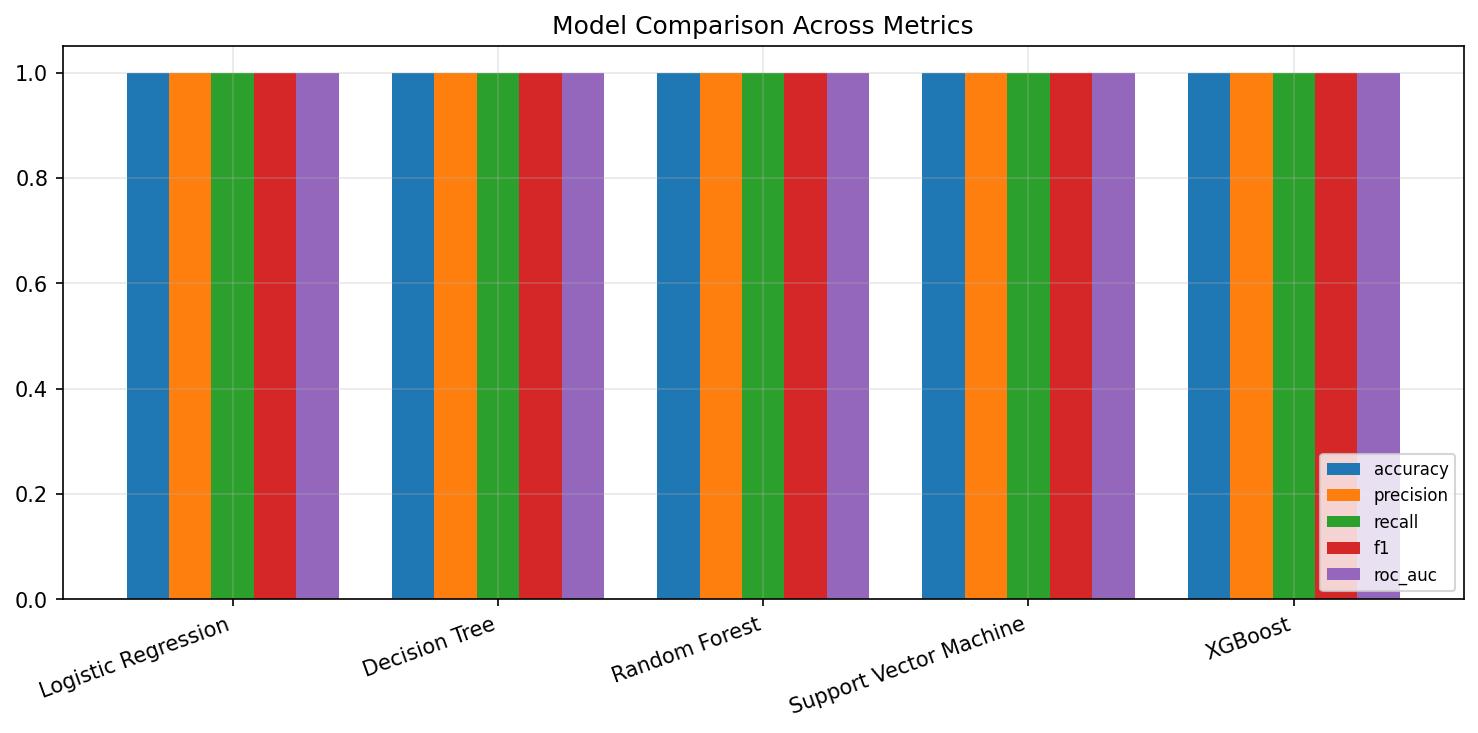

In [4]:
path = viz.plot_model_comparison_table(comparison_df)
display(Image(filename=path))

## Final evaluation on the held-out test set

`run_evaluation_pipeline()` re-evaluates the saved best model on
`data/processed/test.csv` — the split that was never used for model
selection — and additionally runs stratified k-fold cross-validation on the
training set to estimate variance.

In [5]:
eval_summary = run_evaluation_pipeline()
print(f"Model: {eval_summary['model_name']}")
print("Test-set metrics:")
for k, v in eval_summary["test_metrics"].items():
    print(f"  {k:10s}: {v:.4f}")

2026-08-07 10:16:24 | INFO     | src.evaluate | Loaded model 'Logistic Regression' and associated artifacts


2026-08-07 10:16:24 | INFO     | src.feature_engineering | Extracting 25 lexical features for 330 URLs


Extracting features:   0%|          | 0/330 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 330/330 [00:00<00:00, 16293.54it/s]

2026-08-07 10:16:24 | INFO     | src.feature_engineering | Feature matrix built: shape=(330, 26)


...

2026-08-07 10:16:25 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/confusion_matrix_logistic_regression.png


2026-08-07 10:16:25 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/roc_curves_comparison.png


2026-08-07 10:16:25 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/precision_recall_curves_comparison.png


2026-08-07 10:16:25 | INFO     | src.evaluate | Evaluation pipeline complete.


Model: Logistic Regression
Test-set metrics:
  accuracy  : 1.0000
  precision : 1.0000
  recall    : 1.0000
  f1        : 1.0000
  roc_auc   : 1.0000


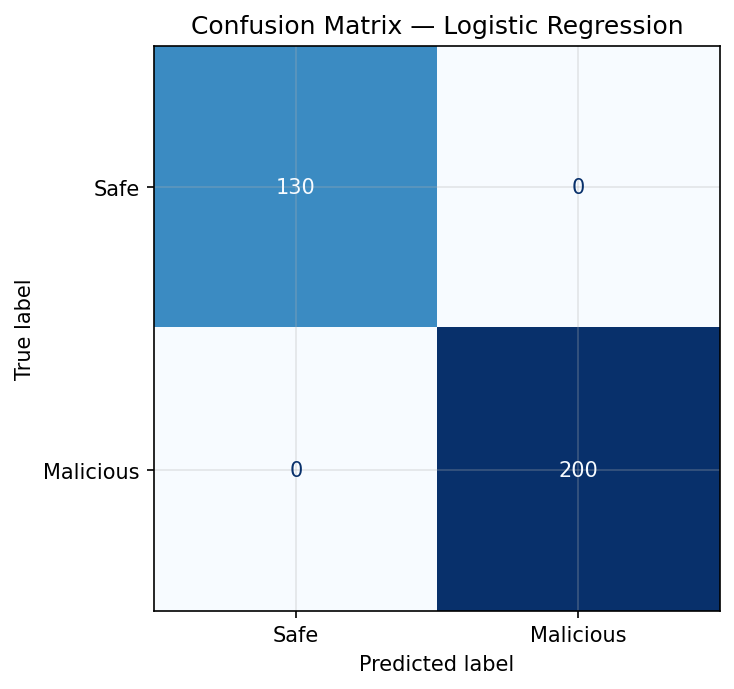

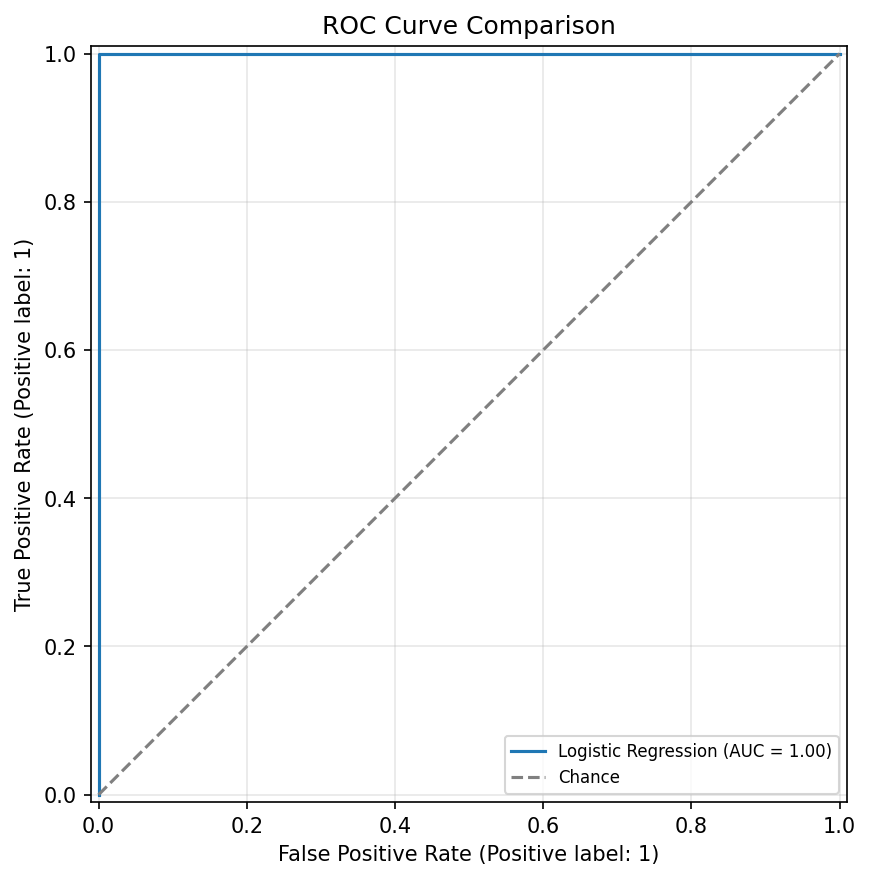

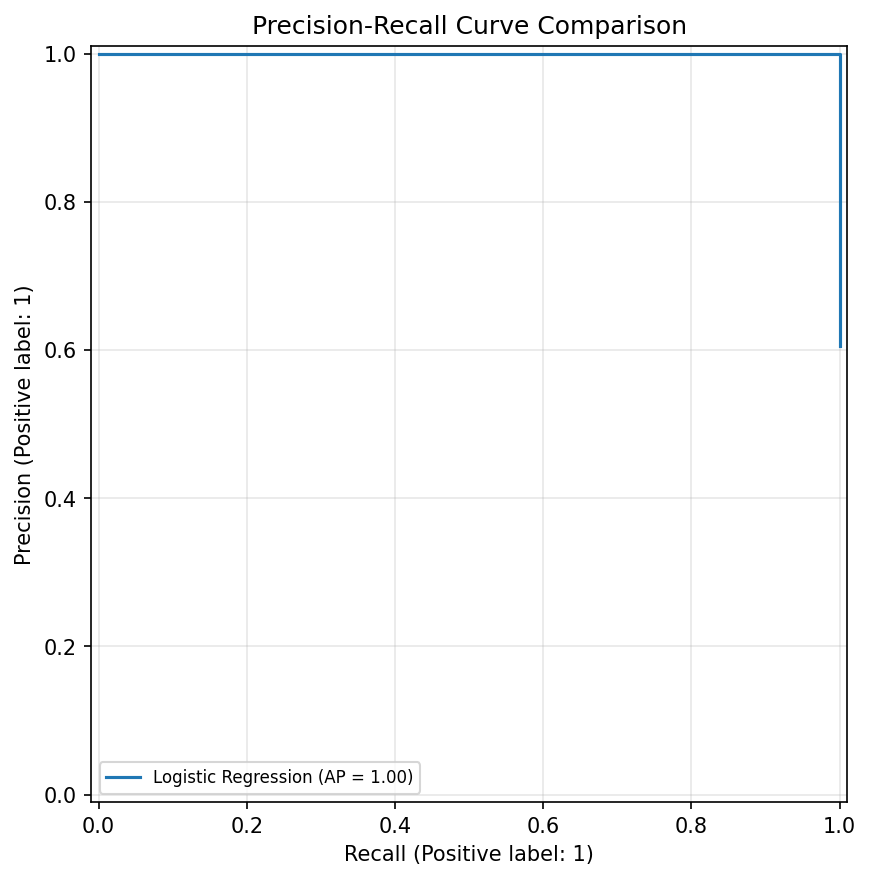

In [6]:
display(Image(filename=eval_summary["paths"]["confusion_matrix"]))
display(Image(filename=eval_summary["paths"]["roc_curve"]))
display(Image(filename=eval_summary["paths"]["pr_curve"]))

In [7]:
with open(eval_summary["paths"]["classification_report"]) as f:
    print(f.read())

Classification Report — Logistic Regression

              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       130
   Malicious       1.00      1.00      1.00       200

    accuracy                           1.00       330
   macro avg       1.00      1.00      1.00       330
weighted avg       1.00      1.00      1.00       330



## Cross-validation stability

In [8]:
cv_df = pd.DataFrame(eval_summary["cv_results"]).T
cv_df.columns = ["mean", "std"]
cv_df

,mean,std
accuracy,1.0,0.000000e+00
precision,1.0,0.000000e+00
recall,1.0,0.000000e+00
f1,1.0,0.000000e+00
roc_auc,1.0,7.021667e-17


## Explainability (SHAP)

`run_explainability_pipeline()` selects a SHAP explainer appropriate to the
winning model's type (`TreeExplainer` for tree-based models, a
permutation-based `Explainer` otherwise), computes SHAP values on a sample of
the test set, and produces global importance, summary, and waterfall plots.

In [9]:
explain_summary = run_explainability_pipeline(sample_size=150, background_size=80)
print(f"Explainer type used: {explain_summary['explainer_kind']}")
print("\nTop features driving Malicious classification:")
for item in explain_summary["top_features"][:10]:
    print(f"  {item['feature']:28s} mean|SHAP| = {item['mean_abs_shap']:.4f}")

2026-08-07 10:16:25 | INFO     | src.evaluate | Loaded model 'Logistic Regression' and associated artifacts


2026-08-07 10:16:25 | INFO     | src.feature_engineering | Extracting 25 lexical features for 1317 URLs


Extracting features:   0%|          | 0/1317 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 1317/1317 [00:00<00:00, 17164.13it/s]

2026-08-07 10:16:25 | INFO     | src.feature_engineering | Feature matrix built: shape=(1317, 26)


...

/home/claude/malicious_url_detector/src/explainability.py:201: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


2026-08-07 10:16:36 | INFO     | src.explainability | Saved SHAP summary plot to /home/claude/malicious_url_detector/results/figures/shap_summary_plot.png


2026-08-07 10:16:36 | INFO     | src.explainability | Saved SHAP waterfall plot (test row index 0) to /home/claude/malicious_url_detector/results/figures/shap_waterfall_malicious_example.png


2026-08-07 10:16:36 | INFO     | src.explainability | Top 5 features driving Malicious classification: ['num_dots', 'url_length', 'domain_length', 'num_digits', 'num_subdomains']


Explainer type used: generic

Top features driving Malicious classification:
  num_dots                     mean|SHAP| = 0.1244
  url_length                   mean|SHAP| = 0.0719
  domain_length                mean|SHAP| = 0.0631
  num_digits                   mean|SHAP| = 0.0512
  num_subdomains               mean|SHAP| = 0.0454
  has_ip_address               mean|SHAP| = 0.0371
  num_hyphens                  mean|SHAP| = 0.0261
  path_length                  mean|SHAP| = 0.0228
  query_length                 mean|SHAP| = 0.0198
  num_suspicious_keywords      mean|SHAP| = 0.0166


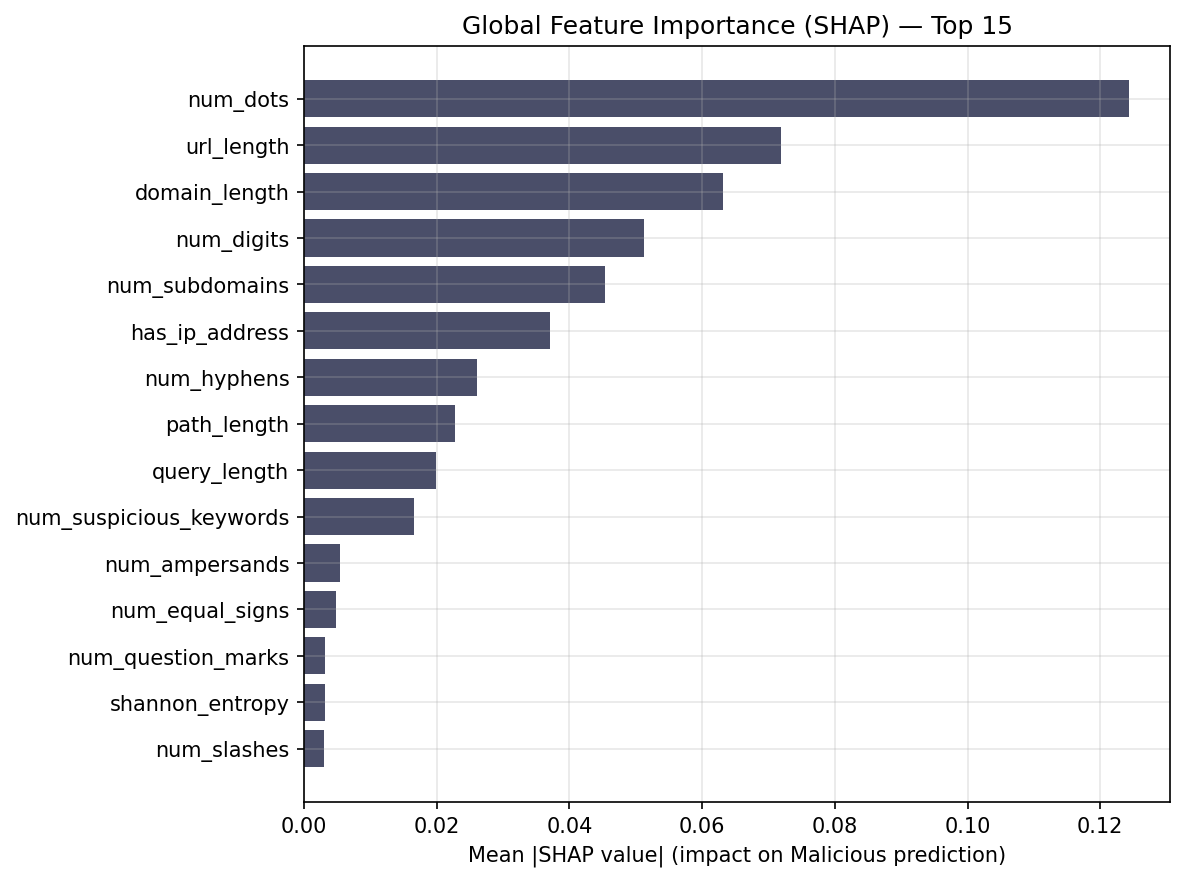

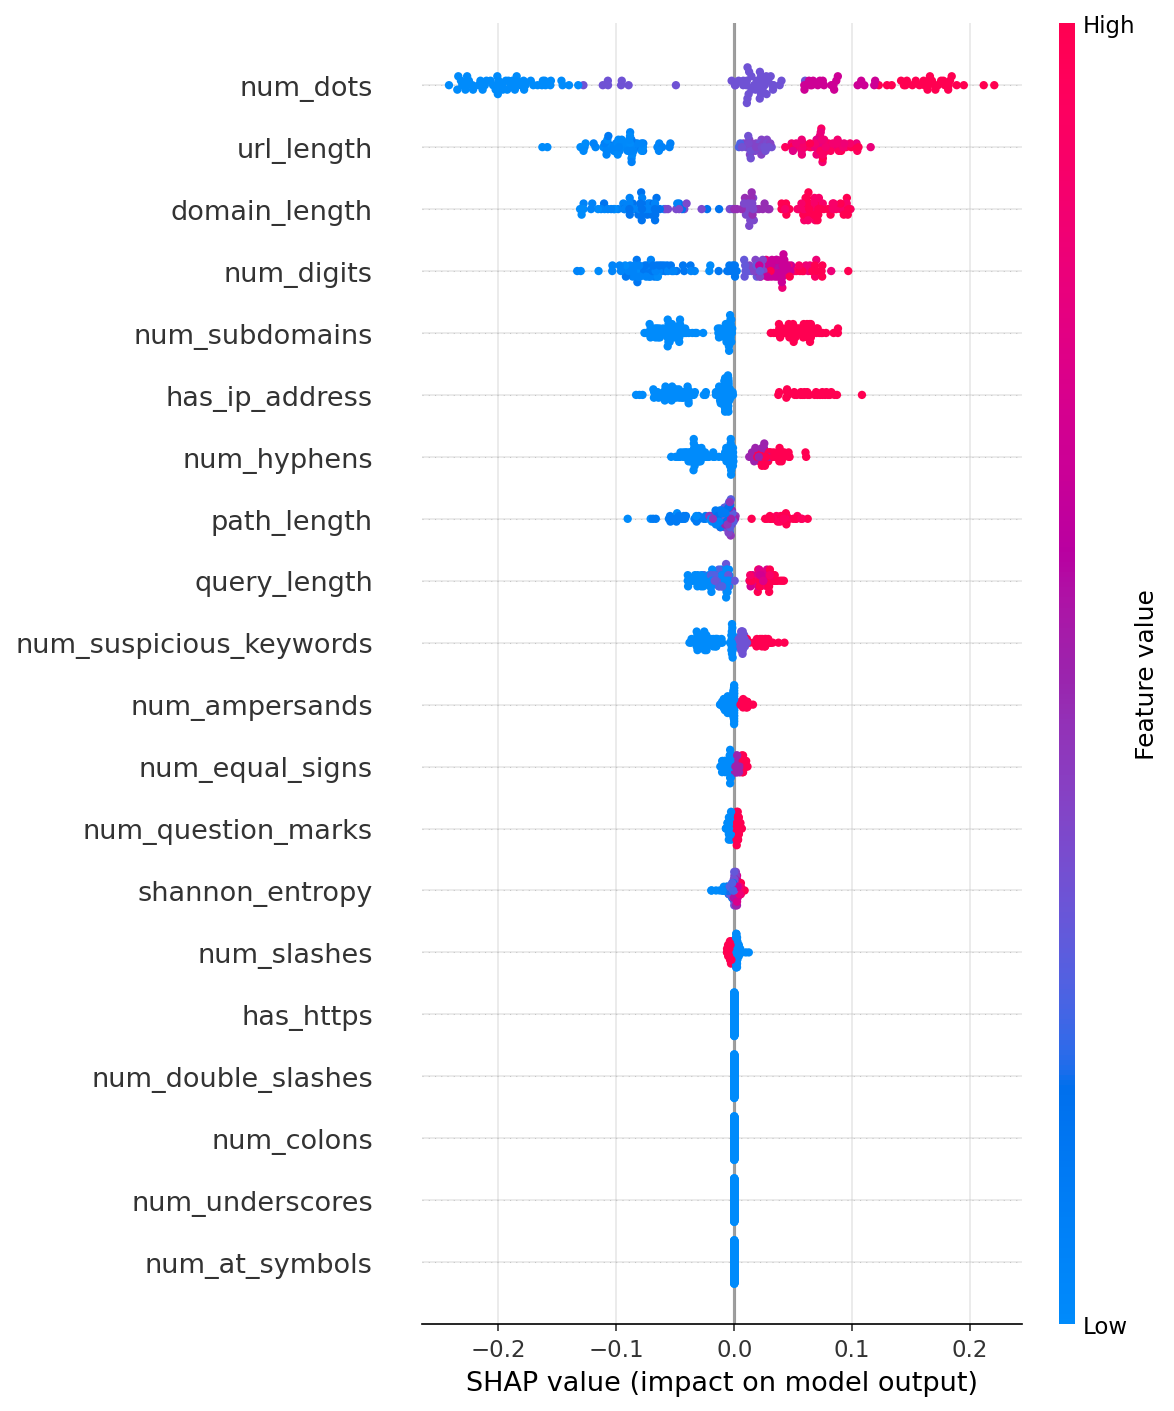

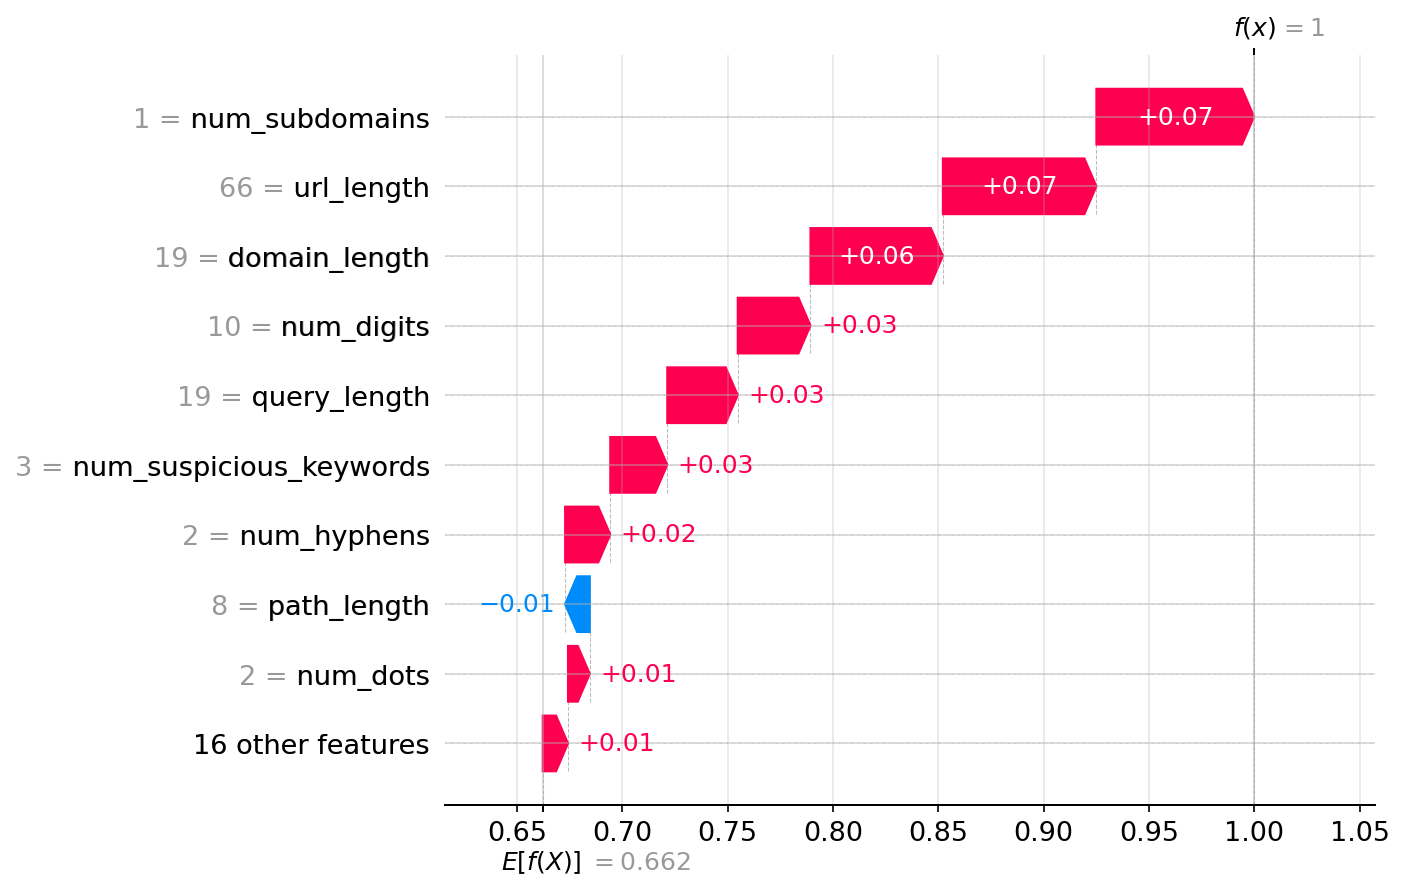

In [10]:
display(Image(filename=explain_summary["paths"]["global_importance"]))
display(Image(filename=explain_summary["paths"]["summary_plot"]))
if explain_summary["paths"]["waterfall_plot"]:
    display(Image(filename=explain_summary["paths"]["waterfall_plot"]))
else:
    print("No correctly-predicted Malicious example was found in this sample for the waterfall plot.")

## Conclusion

The best-performing model (by F1-score, then ROC-AUC) is persisted to
`models/best_model.pkl` and is what `src/predict.py` and the Flask app
(`app/app.py`) load at inference time. The SHAP analysis above identifies
which lexical URL characteristics most strongly drive a Malicious
classification, satisfying the project's explainability requirement.

**Caveat on this notebook's specific numbers:** if this notebook was executed
against the small development/smoke-test dataset rather than the full ~300,000
row Kaggle dataset, the metrics above will look unrealistically high (e.g.
near-perfect scores) because the sample data is trivially separable. Re-run
this notebook (or `python -m src.train` / `evaluate.py` / `explainability.py`
directly, with production tuning settings) against the full dataset before
citing these figures in the dissertation.